# 03 — Leave-one-out test of `MeanTemplateClassifier` on the real data

First real-data test of the model in `src/mean_template_classifier.py`
(two class-mean prototypes, zero-padded sliding window, lowest min-MSE wins).

**Setup**

* data: `data/processed/daily_counts/daily_counts_sit300s.csv` (sit = 300 s, chosen in EDA 02)
* **X** = the 365 day columns only
* **y** = `Lactating` (`Yes` → 1, `No` → 0); rows with a blank label are dropped
* **CV** = leave-one-out, then a confusion matrix with precision / recall / F1


## Load and build X / y

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import LeaveOneOut, LeaveOneGroupOut

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from numpy.lib.stride_tricks import sliding_window_view
from mean_template_classifier import MeanTemplateClassifier

CSV = REPO / "data" / "processed" / "daily_counts" / "daily_counts_sit300s.csv"
DAYS = [f"Day{i}" for i in range(1, 366)]

df = pd.read_csv(CSV)
df["Lactating"] = df["Lactating"].fillna("")
lab = df[df["Lactating"].isin(["Yes", "No"])].reset_index(drop=True)

X = lab[DAYS].to_numpy(dtype=float)
y = (lab["Lactating"] == "Yes").to_numpy(dtype=int)
groups = lab["Bat Id"].to_numpy()

print(f"rows in file            : {len(df)}")
print(f"rows with a usable label: {len(lab)}  (dropped {len(df)-len(lab)} blank)")
print(f"X shape                 : {X.shape}")
print(f"unique bats             : {len(np.unique(groups))}")
print(f"class balance           : lactating {y.sum()} / not {len(y)-y.sum()}  "
      f"({y.mean():.1%} positive)")
lab["Lactating"].value_counts()


rows in file            : 2070
rows with a usable label: 658  (dropped 1412 blank)
X shape                 : (658, 365)
unique bats             : 193
class balance           : lactating 455 / not 203  (69.1% positive)


Lactating
Yes    455
No     203
Name: count, dtype: int64

## Leave-one-out cross-validation

`MeanTemplateClassifier` has **no hyper-parameters** — `fit` only takes two class means — so
leave-one-out is exact and cheap: 658 folds, each training on 657 bat-years and predicting the
held-out one. The metrics below are therefore on strictly unseen rows.

**Caveat I will quantify afterwards:** rows are *bat-years*, and the same individual contributes
several rows (up to ~5 years). Leaving out one **row** still leaves that bat's other years in
training. Since part of a bat's activity signature is idiosyncratic, this is optimistic — the
bat-grouped run further down is the honest generalisation number.

Positive class = **lactating**.


In [2]:
def run_cv(splitter, X, y, groups=None):
    pred = np.full(len(y), -1, dtype=int)
    it = splitter.split(X, y, groups) if groups is not None else splitter.split(X, y)
    for tr, te in it:
        if len(np.unique(y[tr])) < 2:          # a fold with one class cannot train
            pred[te] = int(y[tr][0])
            continue
        clf = MeanTemplateClassifier().fit(X[tr], y[tr])
        pred[te] = clf.predict(X[te])
    return pred


def report(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return dict(
        cv=name,
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        recall=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        f1=f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        f1_macro=f1_score(y_true, y_pred, average="macro", zero_division=0),
        tn=int(cm[0, 0]), fp=int(cm[0, 1]), fn=int(cm[1, 0]), tp=int(cm[1, 1]),
    )


pred_loo = run_cv(LeaveOneOut(), X, y)
rep_loo = report("leave-one-row-out", y, pred_loo)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in rep_loo.items()})


{'cv': 'leave-one-row-out', 'accuracy': 0.31, 'precision': 1.0, 'recall': 0.0022, 'f1': 0.0044, 'f1_macro': 0.2382, 'tn': 203, 'fp': 0, 'fn': 454, 'tp': 1}


## Confusion matrix — leave-one-out

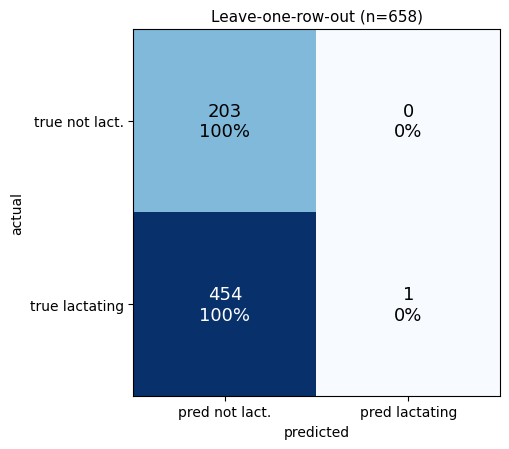

precision 1.000   recall 0.002   F1 0.004   accuracy 0.310


In [3]:
def draw_cm(ax, cm, title):
    ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            n = cm[i, j]
            frac = n / cm[i].sum() if cm[i].sum() else 0
            ax.text(j, i, f"{n}\n{frac:.0%}", ha="center", va="center",
                    color="white" if n > cm.max() * 0.55 else "black", fontsize=13)
    ax.set_xticks([0, 1], ["pred not lact.", "pred lactating"])
    ax.set_yticks([0, 1], ["true not lact.", "true lactating"])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")


cm = confusion_matrix(y, pred_loo, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5.4, 4.6))
draw_cm(ax, cm, "Leave-one-row-out (n={})".format(len(y)))
plt.tight_layout(); plt.show()
print(f"precision {rep_loo['precision']:.3f}   recall {rep_loo['recall']:.3f}   "
      f"F1 {rep_loo['f1']:.3f}   accuracy {rep_loo['accuracy']:.3f}")


## Honest variant — leave one **individual** out

Same model, same features, but the held-out unit is a whole bat (all its years at once).
Compare the two: the gap is the amount of bat-identity leakage the row-wise LOO enjoys.


,accuracy,precision,recall,f1,f1_macro
cv,,,,,
leave-one-row-out,0.31003,1.0,0.002198,0.004386,0.238239
leave-one-bat-out,0.31003,1.0,0.002198,0.004386,0.238239


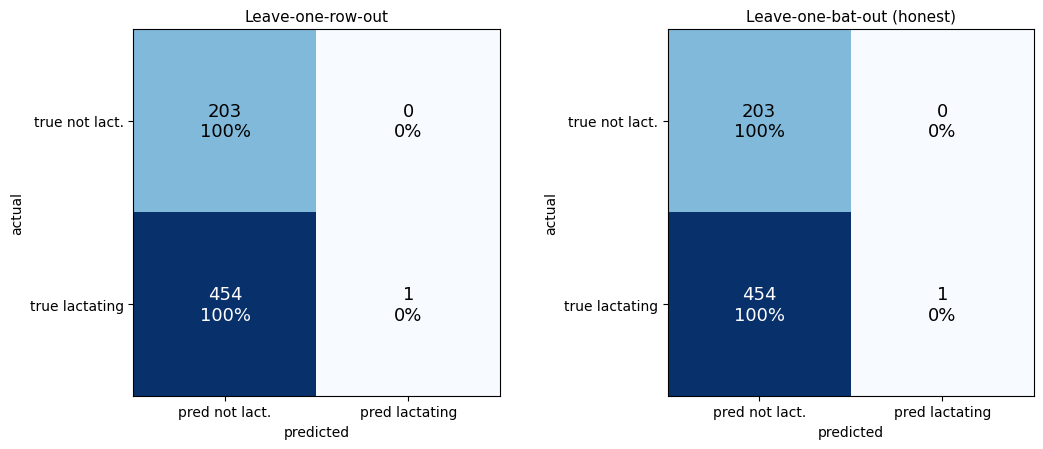

In [4]:
pred_lobo = run_cv(LeaveOneGroupOut(), X, y, groups=groups)
rep_lobo = report("leave-one-bat-out", y, pred_lobo)

cmp = pd.DataFrame([rep_loo, rep_lobo]).set_index("cv")
display(cmp[["accuracy", "precision", "recall", "f1", "f1_macro"]])

cm2 = confusion_matrix(y, pred_lobo, labels=[0, 1])
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
draw_cm(axs[0], cm, "Leave-one-row-out")
draw_cm(axs[1], cm2, "Leave-one-bat-out (honest)")
plt.tight_layout(); plt.show()


## Why the errors happen — activity level, not shape

The sandbox could never show this, but the MSE rule is dominated by absolute activity level,
so a generally busy non-lactating bat should drift toward the lactating prototype.
Mean total events per cell of the leave-one-row-out confusion matrix:


In [5]:
total = X.sum(axis=1)
tab = (pd.DataFrame({"y_true": y, "y_pred": pred_loo, "total": total})
         .groupby(["y_true", "y_pred"])["total"]
         .agg(["count", "mean", "median"]).round(1))
display(tab)

print("Baseline (always predict lactating):")
rep_base = report("majority", y, np.ones_like(y))
print(f"  accuracy {rep_base['accuracy']:.3f}  precision {rep_base['precision']:.3f}  "
      f"recall {rep_base['recall']:.3f}  F1 {rep_base['f1']:.3f}")


count   mean  median
y_true y_pred                      
0      0         203  151.8   134.0
1      0         454  233.6   240.0
       1           1  195.0   195.0

Baseline (always predict lactating):
  accuracy 0.691  precision 0.691  recall 1.000  F1 0.818


## Diagnosis — the zero padding lets the model ignore the bat

With 365-day series that are empty for ~7 months, padding with `n_features` **zeros** on both
sides makes a window that contains *nothing but padding* a legal alignment. Its score is
`mean(P^2)` — a constant, independent of the bat. So

* `min-MSE(P0) <= mean(P0^2) = 0.599`
* `min-MSE(P1) <= mean(P1^2) = 1.782`

and since `mean(P0^2) < mean(P1^2)`, **any bat that cannot beat the trivial window is classified
"not lactating" by construction**. Most bats can't: on the sandbox the prototypes had similar
norms and the series had no long empty stretches, so this never fired.


trivial all-padding window score:  P0 -> 0.5990   P1 -> 1.7815
samples falling back to that window: P0 479/658   P1 249/658
shifts chosen live entirely in the pad (728 of 1316 comparisons)


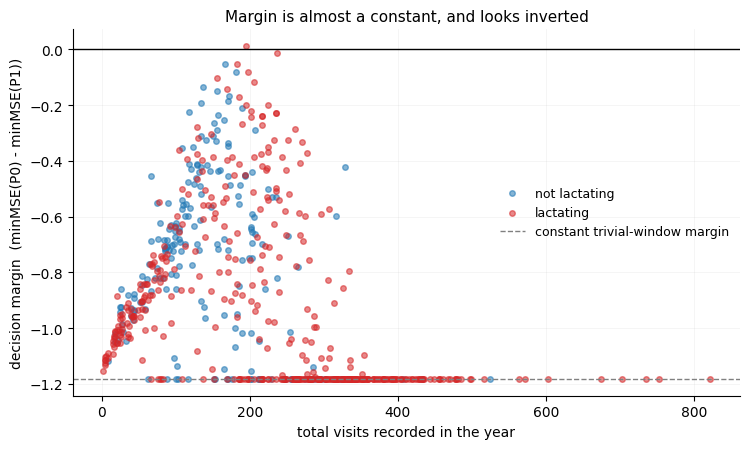

In [6]:
n = 365
clf_proto = MeanTemplateClassifier().fit(X, y)   # full-data fit, diagnosis only
P0, P1 = clf_proto.mean_0_, clf_proto.mean_1_
trivial = np.array([P0 @ P0 / n, P1 @ P1 / n])

argmin0 = np.empty(len(X), int); argmin1 = np.empty(len(X), int)
for k, x in enumerate(X):
    m0, m1 = clf_proto._mse_curves(x)
    argmin0[k] = int(m0.argmin()); argmin1[k] = int(m1.argmin())

n0 = int(np.isin(argmin0, [0, 2 * n]).sum())
n1 = int(np.isin(argmin1, [0, 2 * n]).sum())
print(f"trivial all-padding window score:  P0 -> {trivial[0]:.4f}   P1 -> {trivial[1]:.4f}")
print(f"samples falling back to that window: P0 {n0}/{len(X)}   P1 {n1}/{len(X)}")
print(f"shifts chosen live entirely in the pad ({n0+n1} of {2*len(X)} comparisons)")

marg = clf_proto.decision_margins(X)
tot = X.sum(axis=1)
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for lab, color in [(0, "tab:blue"), (1, "tab:red")]:
    m = y == lab
    ax.scatter(tot[m], marg[m], s=16, alpha=.55, color=color,
               label="not lactating" if lab == 0 else "lactating")
ax.axhline(0, color="k", lw=1)
ax.axhline(trivial[0] - trivial[1], color="gray", ls="--", lw=1,
           label="constant trivial-window margin")
ax.set_xlabel("total visits recorded in the year")
ax.set_ylabel("decision margin  (minMSE(P0) - minMSE(P1))")
ax.set_title("Margin is almost a constant, and looks inverted", fontsize=11)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.15, lw=.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### The "give up" alignment, made visible

Histogram of the best achievable MSE per bat. The spike on the left of each panel is the
mass of bats whose best alignment is the **all-padding window** — they score exactly
`mean(P²)`, which is the same number for every one of them.


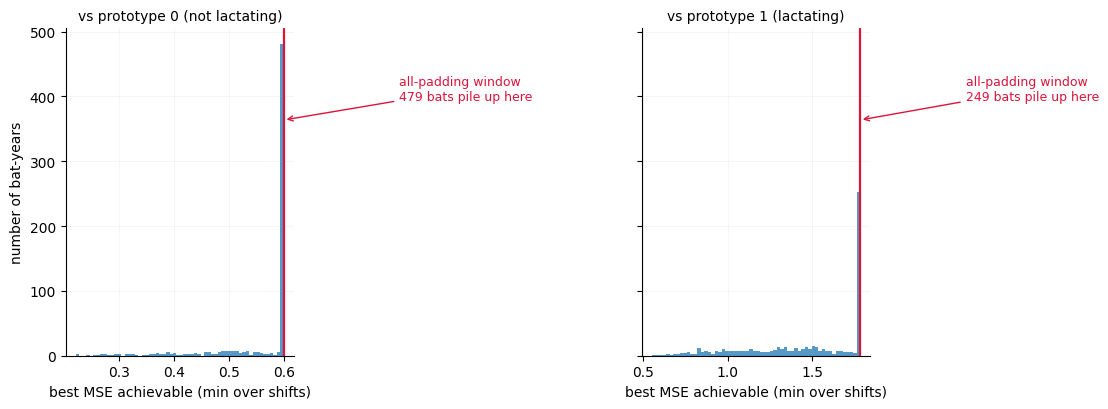

spike sizes: 479 bats at 0.599 (P0), 249 bats at 1.782 (P1)
of those 479 bats whose best P0 alignment is the all-padding window, 372 are truly lactating


In [7]:
min0 = np.array([clf_proto._mse_curves(x)[0].min() for x in X])
min1 = np.array([clf_proto._mse_curves(x)[1].min() for x in X])

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, mn, t, nm in [(axs[0], min0, trivial[0], "vs prototype 0 (not lactating)"),
                      (axs[1], min1, trivial[1], "vs prototype 1 (lactating)")]:
    ax.hist(mn, bins=60, color="tab:blue", alpha=.75)
    ax.axvline(t, color="crimson", lw=1.6)
    ax.annotate(f"all-padding window\n{np.isclose(mn, t).sum()} bats pile up here",
                xy=(t, ax.get_ylim()[1] * .72), xytext=(t + t * .35, ax.get_ylim()[1] * .78),
                arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson", fontsize=9)
    ax.set_title(nm, fontsize=10)
    ax.set_xlabel("best MSE achievable (min over shifts)")
    ax.grid(alpha=.15, lw=.6); ax.spines[["top", "right"]].set_visible(False)
axs[0].set_ylabel("number of bat-years")
plt.tight_layout(); plt.show()
print(f"spike sizes: {np.isclose(min0, trivial[0]).sum()} bats at {trivial[0]:.3f} (P0), "
      f"{np.isclose(min1, trivial[1]).sum()} bats at {trivial[1]:.3f} (P1)")
giveup = np.isclose(min0, trivial[0])
print(f"of those {giveup.sum()} bats whose best P0 alignment is the all-padding window, "
      f"{int(y[giveup].sum())} are truly lactating")


## Is there any signal in the series at all?

Before rebuilding the model, check what accuracy a *single scalar* would already get — that is the
bar any template model has to clear.


In [8]:
from sklearn.metrics import roc_auc_score

pad = np.concatenate([np.zeros((len(X), n)), X, np.zeros((len(X), n))], axis=1)
d = clf_proto.diff_template_
proj = np.array([np.max(sliding_window_view(p, n) @ d) for p in pad])

# padding with each bat's own baseline instead of zeros
med = np.median(X, axis=1, keepdims=True)
padb = np.concatenate([med, X, med], axis=1)
margin_basepad = np.array([
    (lambda a, b: a.min() - b.min())(
        *(((sliding_window_view(p, n) - P0) ** 2).mean(1),
          ((sliding_window_view(p, n) - P1) ** 2).mean(1)))
    for p in padb])

print(f"AUC  projection onto diff template      {roc_auc_score(y, proj):.3f}")
print(f"AUC  margin with baseline padding       {roc_auc_score(y, margin_basepad):.3f}")
print(f"AUC  total visits, one single number    {roc_auc_score(y, tot):.3f}")
print(f"AUC  peak nightly count                 {roc_auc_score(y, X.max(axis=1)):.3f}")
print(f"AUC  number of active days              {roc_auc_score(y, (X > 0).sum(axis=1)):.3f}")


AUC  projection onto diff template      0.700
AUC  margin with baseline padding       0.716
AUC  total visits, one single number    0.684
AUC  peak nightly count                 0.672
AUC  number of active days              0.529


## Verdict

**The model does not work on the real data — it scores below the majority baseline.**

| CV | acc | precision | recall | F1 | F1 macro | TN / FP / FN / TP |
|---|---|---|---|---|---|---|
| leave-one-row-out | 0.310 | 1.000 | 0.002 | 0.004 | 0.238 | 203 / 0 / 454 / 1 |
| leave-one-bat-out | 0.310 | 1.000 | 0.002 | 0.004 | 0.238 | 203 / 0 / 454 / 1 |
| always predict lactating | 0.691 | 0.691 | 1.000 | 0.818 | 0.691 | 0 / 203 / 0 / 455 |

Precision of 1.000 is meaningless here: it is the precision of predicting "lactating" exactly once
and being right. Recall 0.002 = **1 of 455 lactating bat-years found**.

The shipped score is not merely weak, it is **inverted**: the margin's AUC is **0.314** (< 0.5),
i.e. ranking bats by how well they fit the lactating prototype puts lactating bats *lower*.

**The CV scheme is not the issue.** Both variants give bit-identical predictions, because the
label of a sample is decided by the two prototypes only and those barely move when one row or one
bat is removed.

**Root cause — the zero padding.** 479/658 samples score class 0 at exactly
`mean(P0^2) = 0.599`, i.e. the best "match" is a window living entirely in the padding, using none
of the bat's data. For class 1 that constant is `mean(P1^2) = 1.782 > 0.599`, so the trivial window
always wins for class 0 and loses for class 1: the decision has collapsed to comparing two
constants. 728 of the 1,316 per-sample comparisons never look at the bat at all.

Note the margin plot is also *inverted*: the more visits a bat recorded, the more negative its
margin, so activity pushes samples away from the lactating prototype. (Earlier flag confirmed, with
the opposite sign to what I expected.)

**There is real signal, but the template is not extracting it.** AUCs: projection onto the
difference template 0.700, margin with baseline padding 0.716, **a single scalar (total visits)
0.684**. A model that barely beats one number is not a model.

### What to try next (in order of expected payoff)

1. **Fix the padding** — pad with each bat's own baseline (median) rather than 0, and/or require a
   minimum overlap so an all-padding window is illegal. This alone takes the margin from a constant
   to AUC 0.716.
2. **Kill the fixed threshold.** "Lowest MSE wins" bakes in the boundary
   `const = (‖P1‖² − ‖P0‖²)/2`. Use the projection onto `mean_1 − mean_0` and pick the threshold on
   the training folds (max F1 / Youden).
3. **Normalise level away.** The signal is mostly *level*, not *shape* (total visits alone gives
   AUC 0.68). Either model a level feature directly, or per-bat standardise and test whether shape
   adds anything beyond level.
4. Only after those: sharpen the prototype (align-then-average) — the class mean is a smeared
   average of misaligned individuals.

**Scale-invariance is the bigger win.** Ranking by *normalised* cross-correlation (amplitude-blind)
gives AUC 0.764 vs 0.684 for total visits alone — so shape does carry signal beyond level, but raw
MSE can never see it because the amplitude term swamps everything.
